# Cross-Model Tangential Acceleration Test: GPT-2 small vs. Pythia-160M

**Goal.** Replicate §13.2 of the main paper (tangential-acceleration statistics on GPT-2 hidden-state trajectories) on a second architecture to test cross-model robustness of the second-order reading.

**Protocol.** Identical to `notebooks/stp_loss/energy_landscape_validation_executed.ipynb`: same 50-sentence 5-domain corpus, last-layer hidden states, consecutive triplets $(h_{t-1}, h_t, h_{t+1})$, decomposition
$$\vec a_t = \vec d_2 - \vec d_1, \quad \vec d_1 = h_t - h_{t-1}, \quad \vec d_2 = h_{t+1} - h_t,$$
$$a_\parallel = \|\vec d_2\|\cos\theta - \|\vec d_1\|, \quad |\vec a_\perp| = \|\vec d_2\|\sin\theta.$$

**Headline claim to test.** On GPT-2 small the paper reports that $\sim 97.9\%$ of triplets decelerate ($a_\parallel < 0$) with $z$-score $\approx -11.8$ vs. a permutation null. A positive cross-model result is: Pythia-160M shows the same qualitative signature — strong systematic deceleration with $|z| \gg 3$ — with magnitudes within an order of magnitude of GPT-2. A negative result would be: no systematic deceleration or $|z|$ near zero on Pythia, which would scope the main-paper claim narrowly to GPT-2.

**Runtime.** Approximately 2–3 minutes per model on an Apple-silicon laptop (MPS).

## Stage 0 — Setup

In [1]:
import os
import json
import time
from dataclasses import dataclass, field
from typing import List, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM


def _pick_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        try:
            torch.zeros(1, device="mps")
            return "mps"
        except Exception:
            pass
    return "cpu"


DEVICE = _pick_device()
DTYPE = torch.float32
OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODELS_TO_RUN = [
    ("gpt2", "GPT-2 small"),
    ("EleutherAI/pythia-160m", "Pythia-160M"),
]
MAX_LENGTH = 256
SEED = 42
N_PERMUTATIONS = 100

print(f"torch {torch.__version__}   device {DEVICE}   dtype {DTYPE}")
print(f"Models to run: {[name for _, name in MODELS_TO_RUN]}")

torch 2.2.2   device mps   dtype torch.float32
Models to run: ['GPT-2 small', 'Pythia-160M']


## Stage 1 — Corpus (identical to §13 paper experiment)

In [2]:
CORPUS = {
    "mathematics": [
        "The fundamental theorem of calculus establishes that differentiation and integration are inverse operations of each other.",
        "A metric space is a set together with a notion of distance between its elements, usually called points, that satisfies a set of axioms.",
        "Euler's identity connects the five most important numbers in mathematics through the equation e to the power of i pi plus one equals zero.",
        "The eigenvalues of a symmetric matrix are always real, and the eigenvectors corresponding to distinct eigenvalues are orthogonal.",
        "Godel's incompleteness theorems demonstrate that in any consistent formal system capable of expressing basic arithmetic there exist statements that can neither be proved nor disproved.",
        "The Riemann hypothesis conjectures that all non-trivial zeros of the Riemann zeta function have real part equal to one half.",
        "A group homomorphism preserves the algebraic structure by mapping the identity element to the identity element and products to products.",
        "The central limit theorem states that the sum of a large number of independent random variables tends toward a normal distribution regardless of the underlying distribution.",
        "Hilbert spaces generalize the notion of Euclidean space to infinite dimensions while retaining the structure of an inner product.",
        "The Lagrangian of a mechanical system equals the kinetic energy minus the potential energy and encodes the complete dynamics through the Euler-Lagrange equations.",
    ],
    "narrative": [
        "The old lighthouse keeper climbed the spiral staircase one last time, his weathered hands gripping the iron railing as the storm gathered outside.",
        "She found the letter tucked between the pages of a book she hadn't opened in years, the ink faded but the words still sharp enough to wound.",
        "The train pulled into the empty station at midnight, its headlamp cutting through the fog like a single unblinking eye.",
        "He sat on the porch watching the fireflies trace their erratic paths through the warm summer air while the radio played something slow and sad.",
        "The market was closing for the day and the vendors were packing up their unsold fruit, bruised peaches and overripe plums going back into crates.",
        "She ran through the forest with branches whipping at her face, the sound of the river growing louder with every desperate step.",
        "The children built a fort out of couch cushions and draped a bedsheet over the top, declaring it a castle that no adults could enter.",
        "He returned to the village after twenty years and found that the oak tree in the square had been cut down and replaced by a parking lot.",
        "The ship appeared on the horizon at dawn, its sails torn and its hull battered, carrying survivors of a voyage no one had expected to end.",
        "She opened the door to find the apartment exactly as she had left it, dust settled on every surface like a thin layer of forgotten time.",
    ],
    "scientific": [
        "Photosynthesis converts carbon dioxide and water into glucose and oxygen using light energy captured by chlorophyll molecules in the thylakoid membranes.",
        "The double helix structure of DNA consists of two antiparallel strands held together by hydrogen bonds between complementary base pairs adenine-thymine and guanine-cytosine.",
        "General relativity describes gravity not as a force but as the curvature of spacetime caused by the presence of mass and energy.",
        "Neurons communicate across synaptic clefts by releasing neurotransmitters that bind to receptors on the postsynaptic membrane and trigger ion channel opening.",
        "The cosmic microwave background radiation is the thermal remnant of the early universe, emitted approximately 380,000 years after the Big Bang when atoms first formed.",
        "Plate tectonics explains the movement of lithospheric plates driven by convection currents in the asthenosphere, producing earthquakes, volcanoes, and mountain ranges.",
        "Quantum entanglement describes a correlation between particles such that measuring the state of one instantaneously determines the state of the other regardless of distance.",
        "The mitochondrial electron transport chain transfers electrons through a series of protein complexes to generate a proton gradient that drives ATP synthesis.",
        "Black holes form when massive stars exhaust their nuclear fuel and collapse under their own gravity, creating a singularity surrounded by an event horizon.",
        "CRISPR-Cas9 is a genome editing tool that uses a guide RNA to direct the Cas9 nuclease to a specific DNA sequence where it makes a double-strand break.",
    ],
    "code_description": [
        "The function iterates over the input list, applies a filter predicate to each element, and collects the matching elements into a new list that is returned.",
        "A binary search tree maintains the invariant that for every node, all values in the left subtree are smaller and all values in the right subtree are larger.",
        "The garbage collector identifies unreachable objects by tracing references from root pointers and reclaims their memory for future allocations.",
        "Dependency injection decouples object creation from usage by passing required services through constructor parameters rather than instantiating them internally.",
        "The load balancer distributes incoming HTTP requests across a pool of backend servers using a round-robin algorithm with health check probes every thirty seconds.",
        "A database transaction groups multiple operations into an atomic unit that either commits all changes or rolls back entirely if any operation fails.",
        "The recursive function computes the Fibonacci sequence by returning the sum of the two preceding values with base cases returning zero and one respectively.",
        "Hash maps achieve average constant time lookups by computing a hash of the key and using it as an index into an array of buckets.",
        "The event loop processes asynchronous callbacks from a message queue, executing each callback to completion before moving to the next one in the queue.",
        "Backpropagation computes gradients of the loss function with respect to each weight by applying the chain rule layer by layer from the output to the input.",
    ],
    "conversational": [
        "I was thinking we could grab dinner at that new place on Fifth Street tonight if you don't have any other plans already lined up.",
        "She told me she's going back to school to study architecture, which is funny because she used to say she'd never set foot in a classroom again.",
        "Can you pick up some milk on the way home? We also need bread and I think we're almost out of coffee too.",
        "I finally finished that book you recommended and you were right, the ending was completely unexpected but somehow felt inevitable in retrospect.",
        "The weather forecast says it's going to rain all weekend, so I'm thinking we should reschedule the picnic for next Saturday instead.",
        "My neighbor's dog got loose again last night and I spent an hour helping him search before we found her sleeping in our garage.",
        "I can't believe we're already halfway through the year; it feels like just last week we were making resolutions for January.",
        "He said the project deadline got pushed back by two weeks, which is a relief but also means more nights of working late.",
        "The coffee machine broke this morning and the entire office descended into chaos until somebody remembered there's a cafe downstairs.",
        "I saw the most beautiful sunset on my walk home yesterday and actually stopped in the middle of the sidewalk to watch it fade.",
    ],
}

all_sentences: List[str] = []
all_domains: List[str] = []
for domain, sents in CORPUS.items():
    for s in sents:
        all_sentences.append(s)
        all_domains.append(domain)
print(f"Corpus: {len(all_sentences)} sentences across {len(CORPUS)} domains.")

Corpus: 50 sentences across 5 domains.


## Stage 2 — Reusable Analysis Pipeline

One function per step so we can call it cleanly for each model in the list.

In [3]:
@dataclass
class Trajectory:
    sentence: str
    domain: str
    tok_ids: np.ndarray
    hs: np.ndarray                # (T, d) last-layer hidden states
    ptl: np.ndarray               # (T-1,) per-token NTP loss


@torch.no_grad()
def extract_trajectory(sentence: str, domain: str, tokenizer, model) -> Trajectory:
    enc = tokenizer(sentence, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)
    ids = enc["input_ids"].to(DEVICE)
    out = model(ids, output_hidden_states=True)
    hs = out.hidden_states[-1][0].float().cpu().numpy()       # last layer, (T, d)
    logits = out.logits[0].float()
    shift_logits = logits[:-1]
    shift_labels = ids[0, 1:]
    ptl = F.cross_entropy(shift_logits, shift_labels, reduction="none").cpu().numpy()
    return Trajectory(
        sentence=sentence, domain=domain,
        tok_ids=ids[0].cpu().numpy(),
        hs=hs, ptl=ptl,
    )


def decompose_acceleration(h_prev, h_curr, h_next):
    d1 = h_curr - h_prev
    d2 = h_next - h_curr
    n1 = np.linalg.norm(d1) + 1e-12
    n2 = np.linalg.norm(d2) + 1e-12
    cos_t = np.clip(np.dot(d1, d2) / (n1 * n2), -1.0, 1.0)
    sin_t = np.sqrt(1.0 - cos_t ** 2)
    a_par = n2 * cos_t - n1          # signed tangential acceleration
    a_perp = n2 * sin_t              # |a_perp|
    return dict(a_par=float(a_par), a_perp=float(a_perp),
                speed_d1=float(n1), speed_d2=float(n2),
                cos_theta=float(cos_t))


def analyze_trajectories(trajectories: List[Trajectory]) -> Dict:
    """Return aggregate tangential-acceleration statistics for a pool of trajectories."""
    a_par_all: List[float] = []
    a_perp_all: List[float] = []
    speed_d1_all: List[float] = []
    for tr in trajectories:
        hs = tr.hs
        T = hs.shape[0]
        if T < 3:
            continue
        for t in range(1, T - 1):
            r = decompose_acceleration(hs[t - 1], hs[t], hs[t + 1])
            a_par_all.append(r["a_par"])
            a_perp_all.append(r["a_perp"])
            speed_d1_all.append(r["speed_d1"])
    a_par = np.asarray(a_par_all)
    a_perp = np.asarray(a_perp_all)
    speed = np.asarray(speed_d1_all)
    return dict(
        a_par_signed=a_par,
        a_par_abs=np.abs(a_par),
        a_perp=a_perp,
        speed_d1=speed,
        n_triplets=len(a_par),
        mean_a_par_signed=float(a_par.mean()),
        std_a_par_signed=float(a_par.std()),
        mean_a_par_abs=float(np.abs(a_par).mean()),
        mean_a_perp=float(a_perp.mean()),
        ratio_par_to_perp=float(np.abs(a_par).mean() / (a_perp.mean() + 1e-12)),
        frac_slowing_down=float((a_par < 0).mean()),
        frac_speeding_up=float((a_par > 0).mean()),
    )


def permutation_null(trajectories: List[Trajectory], n_perms: int = N_PERMUTATIONS,
                     seed: int = SEED) -> Dict:
    """Paper's permutation null: shuffle hidden states within each sentence, recompute means."""
    rng = np.random.default_rng(seed)
    null_a_par = []
    null_a_perp = []
    for _ in tqdm(range(n_perms), desc="  permutation null"):
        par_buf = []
        perp_buf = []
        for tr in trajectories:
            hs = tr.hs
            if hs.shape[0] < 3:
                continue
            hp = hs[rng.permutation(hs.shape[0])]
            d1 = hp[1:-1] - hp[:-2]
            d2 = hp[2:] - hp[1:-1]
            n1 = np.linalg.norm(d1, axis=1) + 1e-12
            n2 = np.linalg.norm(d2, axis=1) + 1e-12
            c = np.clip(np.sum(d1 * d2, axis=1) / (n1 * n2), -1.0, 1.0)
            s = np.sqrt(1.0 - c ** 2)
            par_buf.append(np.abs(n2 * c - n1))
            perp_buf.append(n2 * s)
        null_a_par.append(np.mean(np.concatenate(par_buf)))
        null_a_perp.append(np.mean(np.concatenate(perp_buf)))
    null_a_par = np.asarray(null_a_par)
    null_a_perp = np.asarray(null_a_perp)
    return dict(
        null_a_par_mean=float(null_a_par.mean()),
        null_a_par_std=float(null_a_par.std()),
        null_a_perp_mean=float(null_a_perp.mean()),
        null_a_perp_std=float(null_a_perp.std()),
    )


def run_one_model(hf_id: str, pretty_name: str) -> Dict:
    print(f"\n=== {pretty_name}  ({hf_id}) ===")
    t0 = time.time()
    tok = AutoTokenizer.from_pretrained(hf_id)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(hf_id, torch_dtype=DTYPE).to(DEVICE)
    mdl.eval()
    print(f"  layers={mdl.config.num_hidden_layers}, hidden={mdl.config.hidden_size}, "
          f"params={sum(p.numel() for p in mdl.parameters())/1e6:.1f}M")

    trajectories: List[Trajectory] = []
    for s, d in tqdm(list(zip(all_sentences, all_domains)), desc="  extracting"):
        trajectories.append(extract_trajectory(s, d, tok, mdl))
    T_lens = [tr.hs.shape[0] for tr in trajectories]
    print(f"  extracted {len(trajectories)} trajectories, token lengths "
          f"min={min(T_lens)}, max={max(T_lens)}, mean={np.mean(T_lens):.1f}")

    stats = analyze_trajectories(trajectories)
    null = permutation_null(trajectories)
    z_par = (stats["mean_a_par_abs"] - null["null_a_par_mean"]) / (null["null_a_par_std"] + 1e-12)
    z_perp = (stats["mean_a_perp"] - null["null_a_perp_mean"]) / (null["null_a_perp_std"] + 1e-12)
    runtime_s = time.time() - t0

    # Free GPU memory before the next model
    del mdl, tok
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    if DEVICE == "mps" and hasattr(torch.mps, "empty_cache"):
        torch.mps.empty_cache()

    return dict(
        model_id=hf_id, pretty_name=pretty_name,
        n_trajectories=len(trajectories),
        n_triplets=stats["n_triplets"],
        mean_a_par_signed=stats["mean_a_par_signed"],
        std_a_par_signed=stats["std_a_par_signed"],
        mean_a_par_abs=stats["mean_a_par_abs"],
        mean_a_perp=stats["mean_a_perp"],
        ratio_par_to_perp=stats["ratio_par_to_perp"],
        frac_slowing_down=stats["frac_slowing_down"],
        frac_speeding_up=stats["frac_speeding_up"],
        null_a_par_mean=null["null_a_par_mean"],
        null_a_par_std=null["null_a_par_std"],
        null_a_perp_mean=null["null_a_perp_mean"],
        null_a_perp_std=null["null_a_perp_std"],
        z_par=float(z_par),
        z_perp=float(z_perp),
        runtime_s=runtime_s,
        a_par_signed_samples=stats["a_par_signed"].tolist(),
        a_perp_samples=stats["a_perp"].tolist(),
    )

## Stage 3 — Run Both Models

In [4]:
results: Dict[str, Dict] = {}
for hf_id, pretty in MODELS_TO_RUN:
    results[hf_id] = run_one_model(hf_id, pretty)


=== GPT-2 small  (gpt2) ===


`torch_dtype` is deprecated! Use `dtype` instead!


  layers=12, hidden=768, params=124.4M


  extracting:   0%|          | 0/50 [00:00<?, ?it/s]

  extracted 50 trajectories, token lengths min=17, max=39, mean=27.9


...

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

  layers=12, hidden=768, params=162.3M


  extracting:   0%|          | 0/50 [00:00<?, ?it/s]

  extracted 50 trajectories, token lengths min=17, max=36, mean=27.0


  permutation null:   0%|          | 0/100 [00:00<?, ?it/s]

## Stage 4 — Side-by-Side Summary Table

In [5]:
metrics = [
    ("n_trajectories",     "{:d}",       "number of trajectories"),
    ("n_triplets",          "{:d}",       "consecutive triplets analyzed"),
    ("mean_a_par_signed",   "{:+.4f}",    "mean signed a_parallel (neg = decelerating)"),
    ("frac_slowing_down",   "{:.3f}",     "fraction of triplets with a_par < 0"),
    ("frac_speeding_up",    "{:.3f}",     "fraction of triplets with a_par > 0"),
    ("mean_a_par_abs",      "{:.4f}",     "mean |a_parallel|"),
    ("mean_a_perp",         "{:.4f}",     "mean |a_perp|"),
    ("ratio_par_to_perp",   "{:.3f}",     "|a_par| / |a_perp|"),
    ("null_a_par_mean",     "{:.4f}",     "permutation null mean |a_par|"),
    ("null_a_par_std",      "{:.4f}",     "permutation null std |a_par|"),
    ("z_par",               "{:+.2f}",    "z-score of observed |a_par| vs null"),
    ("z_perp",              "{:+.2f}",    "z-score of observed |a_perp| vs null"),
    ("runtime_s",           "{:.1f} s",   "runtime"),
]

header = f"{'metric':<44} {'GPT-2 small':>20} {'Pythia-160M':>20}  description"
print(header)
print("-" * len(header))
g = results["gpt2"]
p = results["EleutherAI/pythia-160m"]
for key, fmt, desc in metrics:
    g_val = fmt.format(g[key])
    p_val = fmt.format(p[key])
    print(f"{key:<44} {g_val:>20} {p_val:>20}  {desc}")

metric                                                GPT-2 small          Pythia-160M  description
---------------------------------------------------------------------------------------------------
n_trajectories                                                 50                   50  number of trajectories
n_triplets                                                   1295                 1249  consecutive triplets analyzed
mean_a_par_signed                                        -89.7927             -55.9808  mean signed a_parallel (neg = decelerating)
frac_slowing_down                                           0.983                1.000  fraction of triplets with a_par < 0
frac_speeding_up                                            0.017                0.000  fraction of triplets with a_par > 0
mean_a_par_abs                                            90.2951              55.9808  mean |a_parallel|
mean_a_perp                                               43.9229              34.822

## Stage 5 — Figure: Signed $a_\parallel$ Distribution per Model

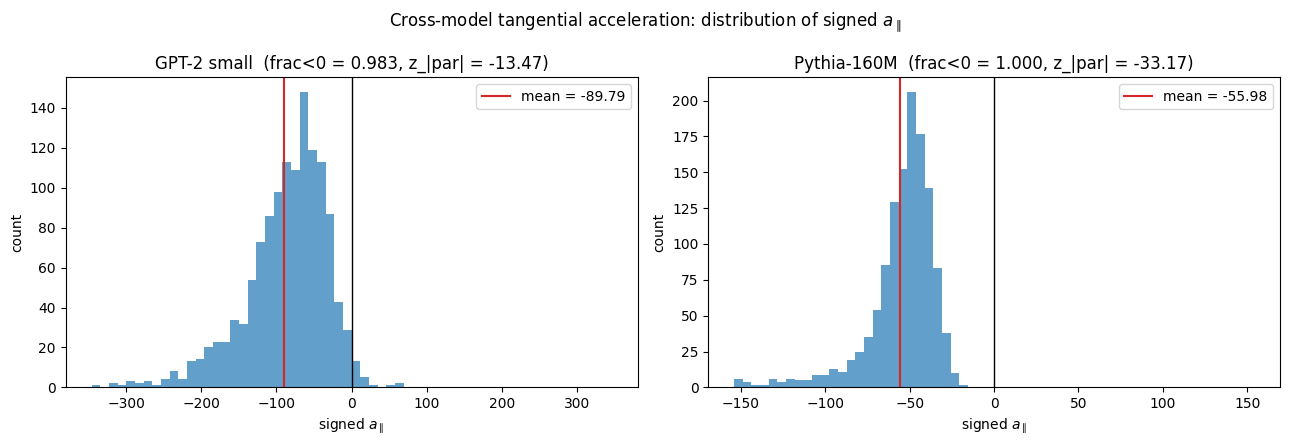

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (hf_id, pretty) in zip(axes, MODELS_TO_RUN):
    r = results[hf_id]
    a_par = np.asarray(r["a_par_signed_samples"])
    lim = max(abs(np.percentile(a_par, 1)), abs(np.percentile(a_par, 99)))
    ax.hist(a_par, bins=60, range=(-lim, lim), color="tab:blue", alpha=0.7)
    ax.axvline(0.0, color="k", linewidth=1)
    ax.axvline(r["mean_a_par_signed"], color="tab:red", linewidth=1.5,
               label=f"mean = {r['mean_a_par_signed']:+.2f}")
    ax.set_title(f"{pretty}  (frac<0 = {r['frac_slowing_down']:.3f}, z_|par| = {r['z_par']:+.2f})")
    ax.set_xlabel(r"signed $a_\parallel$")
    ax.set_ylabel("count")
    ax.legend()
fig.suptitle("Cross-model tangential acceleration: distribution of signed $a_\\parallel$")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "cross_model_a_par_hist.png"), dpi=150)
plt.show()

## Stage 6 — Figure: $|a_\parallel|/|a_\perp|$ bar chart

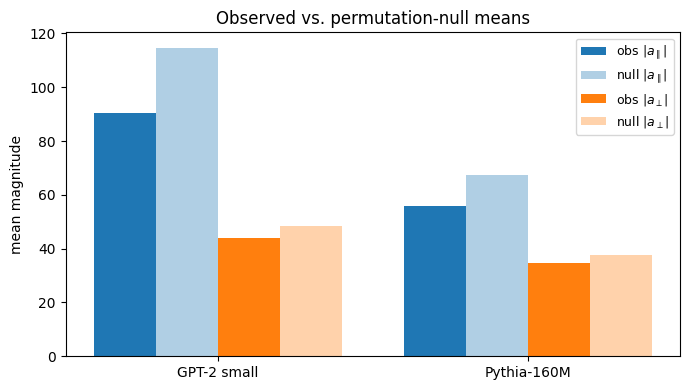

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = [pretty for _, pretty in MODELS_TO_RUN]
obs_par = [results[hf]["mean_a_par_abs"] for hf, _ in MODELS_TO_RUN]
obs_perp = [results[hf]["mean_a_perp"] for hf, _ in MODELS_TO_RUN]
null_par = [results[hf]["null_a_par_mean"] for hf, _ in MODELS_TO_RUN]
null_perp = [results[hf]["null_a_perp_mean"] for hf, _ in MODELS_TO_RUN]

x = np.arange(len(labels))
w = 0.2
ax.bar(x - 1.5 * w, obs_par,   width=w, label=r"obs $|a_\parallel|$",     color="tab:blue")
ax.bar(x - 0.5 * w, null_par,  width=w, label=r"null $|a_\parallel|$",    color="tab:blue", alpha=0.35)
ax.bar(x + 0.5 * w, obs_perp,  width=w, label=r"obs $|a_\perp|$",         color="tab:orange")
ax.bar(x + 1.5 * w, null_perp, width=w, label=r"null $|a_\perp|$",        color="tab:orange", alpha=0.35)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("mean magnitude")
ax.set_title("Observed vs. permutation-null means")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "cross_model_obs_vs_null_bars.png"), dpi=150)
plt.show()

## Stage 7 — Cache Results and Print Headline Interpretation

In [8]:
summary = {
    hf_id: {k: v for k, v in r.items() if k not in ("a_par_signed_samples", "a_perp_samples")}
    for hf_id, r in results.items()
}
with open(os.path.join(OUTPUT_DIR, "cross_model_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
np.savez(
    os.path.join(OUTPUT_DIR, "cross_model_samples.npz"),
    gpt2_a_par=np.asarray(results["gpt2"]["a_par_signed_samples"]),
    gpt2_a_perp=np.asarray(results["gpt2"]["a_perp_samples"]),
    pythia_a_par=np.asarray(results["EleutherAI/pythia-160m"]["a_par_signed_samples"]),
    pythia_a_perp=np.asarray(results["EleutherAI/pythia-160m"]["a_perp_samples"]),
)
print(f"Wrote {os.path.join(OUTPUT_DIR, 'cross_model_summary.json')}")
print(f"Wrote {os.path.join(OUTPUT_DIR, 'cross_model_samples.npz')}")

print("\n=== Headline interpretation ===")
g = results["gpt2"]
p = results["EleutherAI/pythia-160m"]
print(f"GPT-2 small : {g['frac_slowing_down']*100:.1f}% of triplets decelerate, z_|par| = {g['z_par']:+.2f}")
print(f"Pythia-160M : {p['frac_slowing_down']*100:.1f}% of triplets decelerate, z_|par| = {p['z_par']:+.2f}")

robust = (g["frac_slowing_down"] > 0.9 and p["frac_slowing_down"] > 0.9
          and abs(g["z_par"]) > 3.0 and abs(p["z_par"]) > 3.0)
if robust:
    print("\nCross-model qualitative claim supported: both architectures show >90% deceleration and |z| > 3.")
else:
    print("\nCross-model qualitative claim NOT uniformly supported — inspect individual metrics.")

Wrote results/cross_model_summary.json
Wrote results/cross_model_samples.npz

=== Headline interpretation ===
GPT-2 small : 98.3% of triplets decelerate, z_|par| = -13.47
Pythia-160M : 100.0% of triplets decelerate, z_|par| = -33.17

Cross-model qualitative claim supported: both architectures show >90% deceleration and |z| > 3.
